# 🚀 Wisconsin Dataset - Model Training & Comparison

## Mục tiêu
- Training 3 mô hình ML: Logistic Regression, Random Forest, XGBoost
- So sánh hiệu suất các mô hình
- Đánh giá theo tiêu chuẩn y khoa (Sensitivity, Specificity, ROC-AUC)
- Lưu trained models

## 🏥 Tại sao 3 mô hình này?
1. **Logistic Regression**: Baseline y khoa truyền thống, dễ giải thích
2. **Random Forest**: Ensemble method, robust, handle nonlinear
3. **XGBoost**: State-of-the-art gradient boosting, often best performance

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Custom imports
from src.utils.config import *
from src.utils.helpers import *
from src.models.wisconsin_models import WisconsinMLModels
from src.evaluation import (
    calculate_clinical_metrics,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_precision_recall_curve,
    print_clinical_report
)

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Processed Data

In [2]:
# Load processed data
print("📂 Loading processed data...")

data_path = PROCESSED_DATA_DIR / 'wisconsin_processed.pkl'
processed_data = joblib.load(data_path)

X_train = processed_data['X_train']
X_val = processed_data['X_val']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_val = processed_data['y_val']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

print(f"\n✅ Data loaded successfully")
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

📂 Loading processed data...

✅ Data loaded successfully

Training samples: 498
Validation samples: 57
Test samples: 114
Number of features: 30


## 2. Train Models

### Training Strategy:
- Train on training set (with SMOTE)
- Initial evaluation on validation set
- Final evaluation on test set
- Use `class_weight='balanced'` for models

In [3]:
# Initialize model trainer
print_section_header("TRAINING MACHINE LEARNING MODELS")

ml_models = WisconsinMLModels(random_state=RANDOM_STATE)

# Train all models
trained_models = ml_models.train_all_models(
    X_train=X_train,
    y_train=y_train,
    tune=False  # Set to True for hyperparameter tuning (slower)
)

print("\n✅ All models trained successfully!")


                        TRAINING MACHINE LEARNING MODELS                        


🚀 Training Machine Learning Models...

📊 Training Logistic Regression (Baseline)...
   ✅ Completed
📊 Training Random Forest...
   ✅ Completed
📊 Training XGBoost...


   ✅ Completed

✅ All models trained successfully!


✅ All models trained successfully!


## 3. Evaluation on Validation Set

### Quick check before final test evaluation

In [4]:
# Evaluate all models on validation set
print_section_header("VALIDATION SET EVALUATION")

val_results = {}

for model_name, model in trained_models.items():
    print(f"\n📊 Evaluating {model_name}...")
    
    # Predictions
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    metrics = calculate_clinical_metrics(y_val, y_val_pred, y_val_proba)
    val_results[model_name] = metrics
    
    # Print summary
    print(f"   Accuracy:    {metrics['accuracy']:.4f}")
    print(f"   Sensitivity: {metrics['sensitivity']:.4f} ⭐")
    print(f"   Specificity: {metrics['specificity']:.4f}")
    print(f"   ROC-AUC:     {metrics['roc_auc']:.4f}")

print("\n✅ Validation evaluation completed")


                           VALIDATION SET EVALUATION                            


📊 Evaluating Logistic Regression...
   Accuracy:    0.9649
   Sensitivity: 0.9722 ⭐
   Specificity: 0.9524
   ROC-AUC:     0.9921

📊 Evaluating Random Forest...
   Accuracy:    0.9298
   Sensitivity: 0.9444 ⭐
   Specificity: 0.9048
   ROC-AUC:     0.9788

📊 Evaluating XGBoost...
   Accuracy:    0.9474
   Sensitivity: 0.9444 ⭐
   Specificity: 0.9524
   ROC-AUC:     0.9868

✅ Validation evaluation completed


In [5]:
# Validation results comparison
val_results_df = pd.DataFrame(val_results).T
val_results_df = val_results_df.round(4)

print("\n📊 Validation Set Performance Comparison:")
print("="*80)
print(val_results_df)
print("="*80)


📊 Validation Set Performance Comparison:
                     accuracy  sensitivity  specificity     ppv     npv  \
Logistic Regression    0.9649       0.9722       0.9524  0.9722  0.9524   
Random Forest          0.9298       0.9444       0.9048  0.9444  0.9048   
XGBoost                0.9474       0.9444       0.9524  0.9714  0.9091   

                     f1_score  roc_auc  pr_auc  
Logistic Regression    0.9722   0.9921  0.9955  
Random Forest          0.9444   0.9788  0.9845  
XGBoost                0.9577   0.9868  0.9921  


## 4. Test Set Evaluation (Final)

### 🎯 This is the FINAL evaluation for research paper

In [6]:
# Evaluate all models on test set
print_section_header("TEST SET EVALUATION (FINAL)")

test_results = {}
test_predictions = {}

for model_name, model in trained_models.items():
    print(f"\n📊 Evaluating {model_name} on Test Set...")
    
    # Predictions
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Store predictions
    test_predictions[model_name] = {
        'y_pred': y_test_pred,
        'y_proba': y_test_proba
    }
    
    # Calculate metrics
    metrics = calculate_clinical_metrics(y_test, y_test_pred, y_test_proba)
    test_results[model_name] = metrics
    
    # Print detailed report
    print_clinical_report(y_test, y_test_pred, y_test_proba, model_name)

print("\n✅ Test evaluation completed")


                          TEST SET EVALUATION (FINAL)                           


📊 Evaluating Logistic Regression on Test Set...

                CLINICAL EVALUATION REPORT - Logistic Regression                

📊 PERFORMANCE METRICS
--------------------------------------------------------------------------------
Accuracy                           0.9561
Sensitivity (Recall) ⭐             0.9444
Specificity                        0.9762
PPV (Precision)                    0.9855
NPV                                0.9111
F1-Score                           0.9645
ROC-AUC                            0.9931
PR-AUC                             0.9956
--------------------------------------------------------------------------------

📋 CONFUSION MATRIX
--------------------------------------------------------------------------------
True Negatives (TN)                    41
False Positives (FP)                    1
False Negatives (FN)                    4  ⚠️  Missed cancer cases
True Positive

In [7]:
# Test results comparison table
test_results_df = pd.DataFrame(test_results).T
test_results_df = test_results_df.round(4)

print("\n🎯 FINAL TEST SET PERFORMANCE COMPARISON")
print("="*80)
print(test_results_df)
print("="*80)

# Save results
test_results_df.to_csv(RESULTS_DIR / 'wisconsin_test_results.csv')
print(f"\n💾 Results saved to: {RESULTS_DIR / 'wisconsin_test_results.csv'}")


🎯 FINAL TEST SET PERFORMANCE COMPARISON
                     accuracy  sensitivity  specificity     ppv     npv  \
Logistic Regression    0.9561       0.9444       0.9762  0.9855  0.9111   
Random Forest          0.9386       0.9444       0.9286  0.9577  0.9070   
XGBoost                0.9474       0.9583       0.9286  0.9583  0.9286   

                     f1_score  roc_auc  pr_auc  
Logistic Regression    0.9645   0.9931  0.9956  
Random Forest          0.9510   0.9932  0.9960  
XGBoost                0.9583   0.9927  0.9959  

💾 Results saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_test_results.csv


## 5. Visualizations

### Confusion Matrices

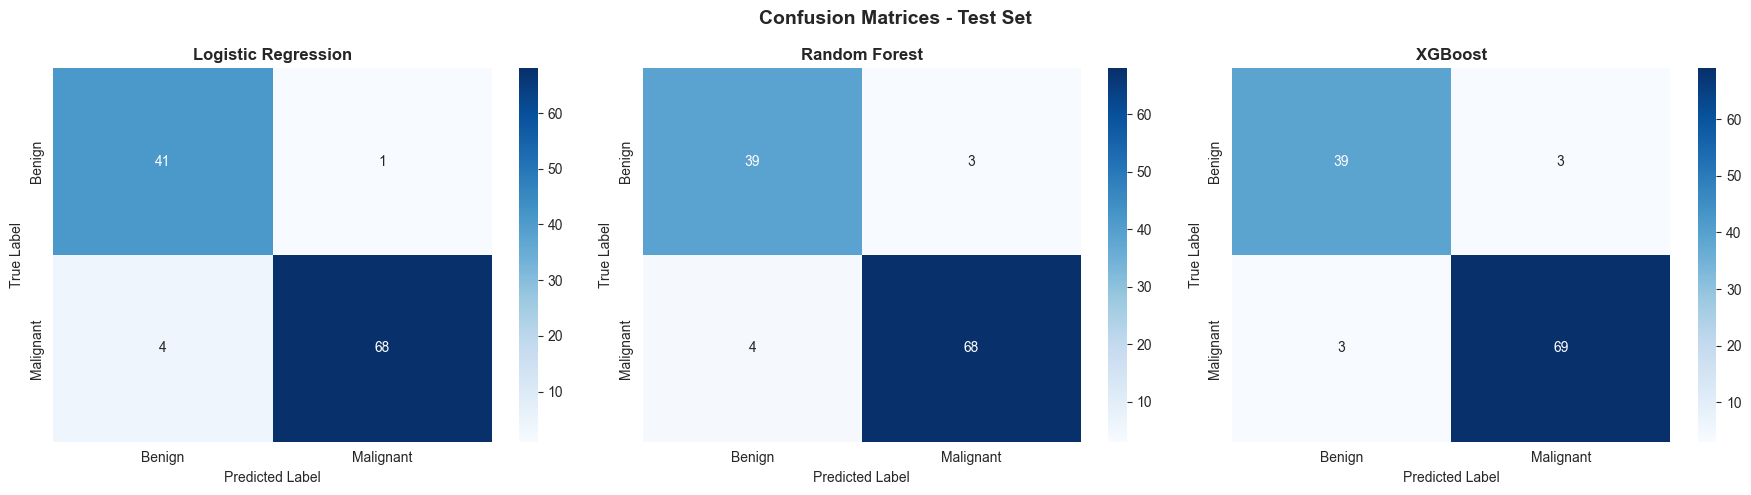

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_confusion_matrices.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_confusion_matrices.png')

In [8]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, preds) in enumerate(test_predictions.items()):
    cm_fig = plot_confusion_matrix(
        y_test, 
        preds['y_pred'],
        title=f'{model_name}',
        figsize=(6, 5)
    )
    plt.close(cm_fig)  # Close individual figure
    
    # Recreate on subplot
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    axes[idx].set_title(model_name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_confusion_matrices', RESULTS_DIR)

### ROC Curves

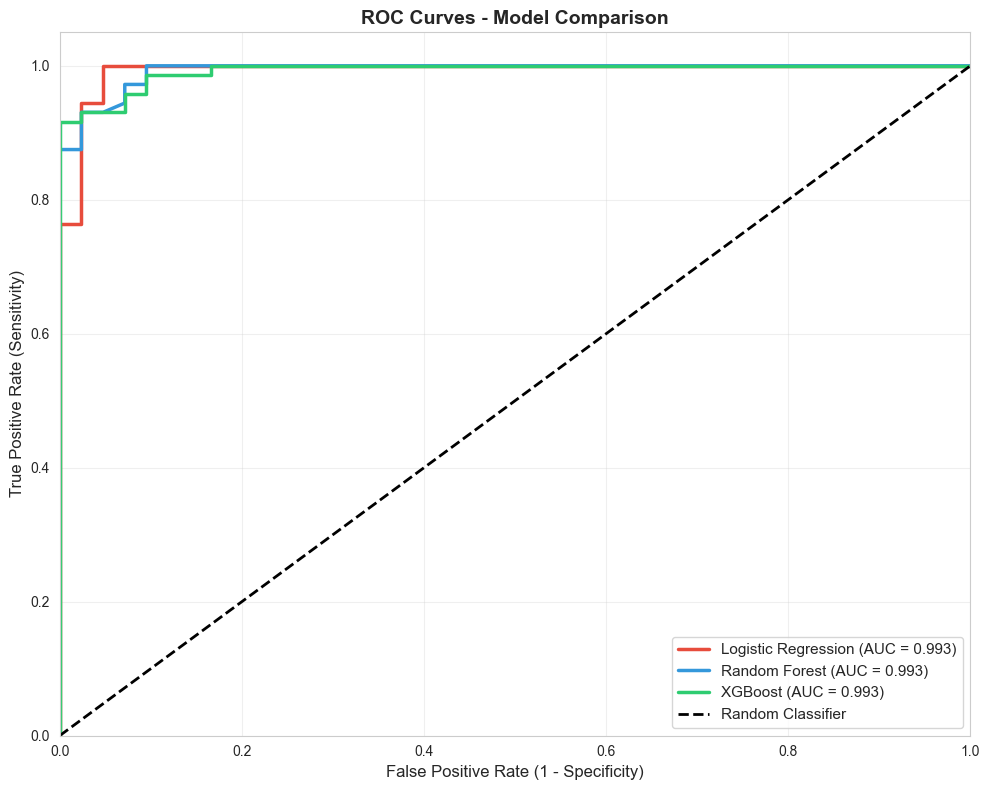

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_roc_curves_comparison.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_roc_curves_comparison.png')

In [9]:
# Plot ROC curves for all models
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71']

for idx, (model_name, preds) in enumerate(test_predictions.items()):
    fpr, tpr, _ = roc_curve(y_test, preds['y_proba'])
    auc = roc_auc_score(y_test, preds['y_proba'])
    
    ax.plot(fpr, tpr, color=colors[idx], lw=2.5, 
            label=f'{model_name} (AUC = {auc:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_roc_curves_comparison', RESULTS_DIR)

### Precision-Recall Curves

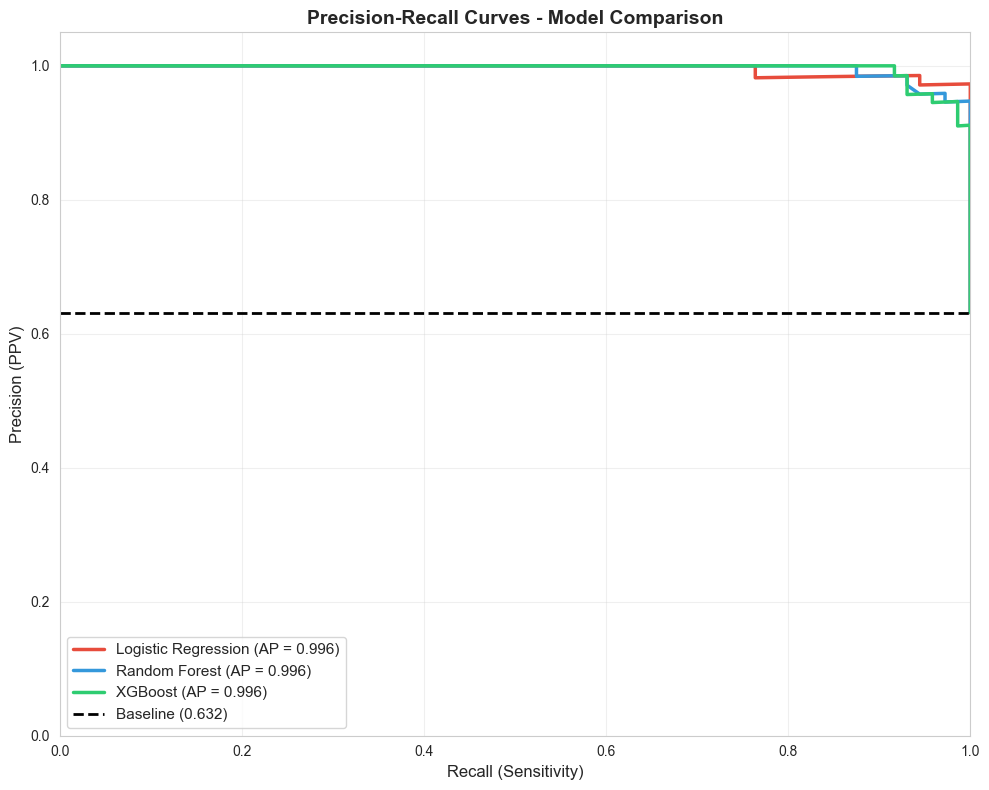

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_pr_curves_comparison.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_pr_curves_comparison.png')

In [10]:
# Plot PR curves for all models
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 8))

for idx, (model_name, preds) in enumerate(test_predictions.items()):
    precision, recall, _ = precision_recall_curve(y_test, preds['y_proba'])
    ap = average_precision_score(y_test, preds['y_proba'])
    
    ax.plot(recall, precision, color=colors[idx], lw=2.5,
            label=f'{model_name} (AP = {ap:.3f})')

# Baseline
baseline = (y_test == 1).sum() / len(y_test)
ax.plot([0, 1], [baseline, baseline], 'k--', lw=2, 
        label=f'Baseline ({baseline:.3f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision (PPV)', fontsize=12)
ax.set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_pr_curves_comparison', RESULTS_DIR)

### Metrics Comparison Bar Plot

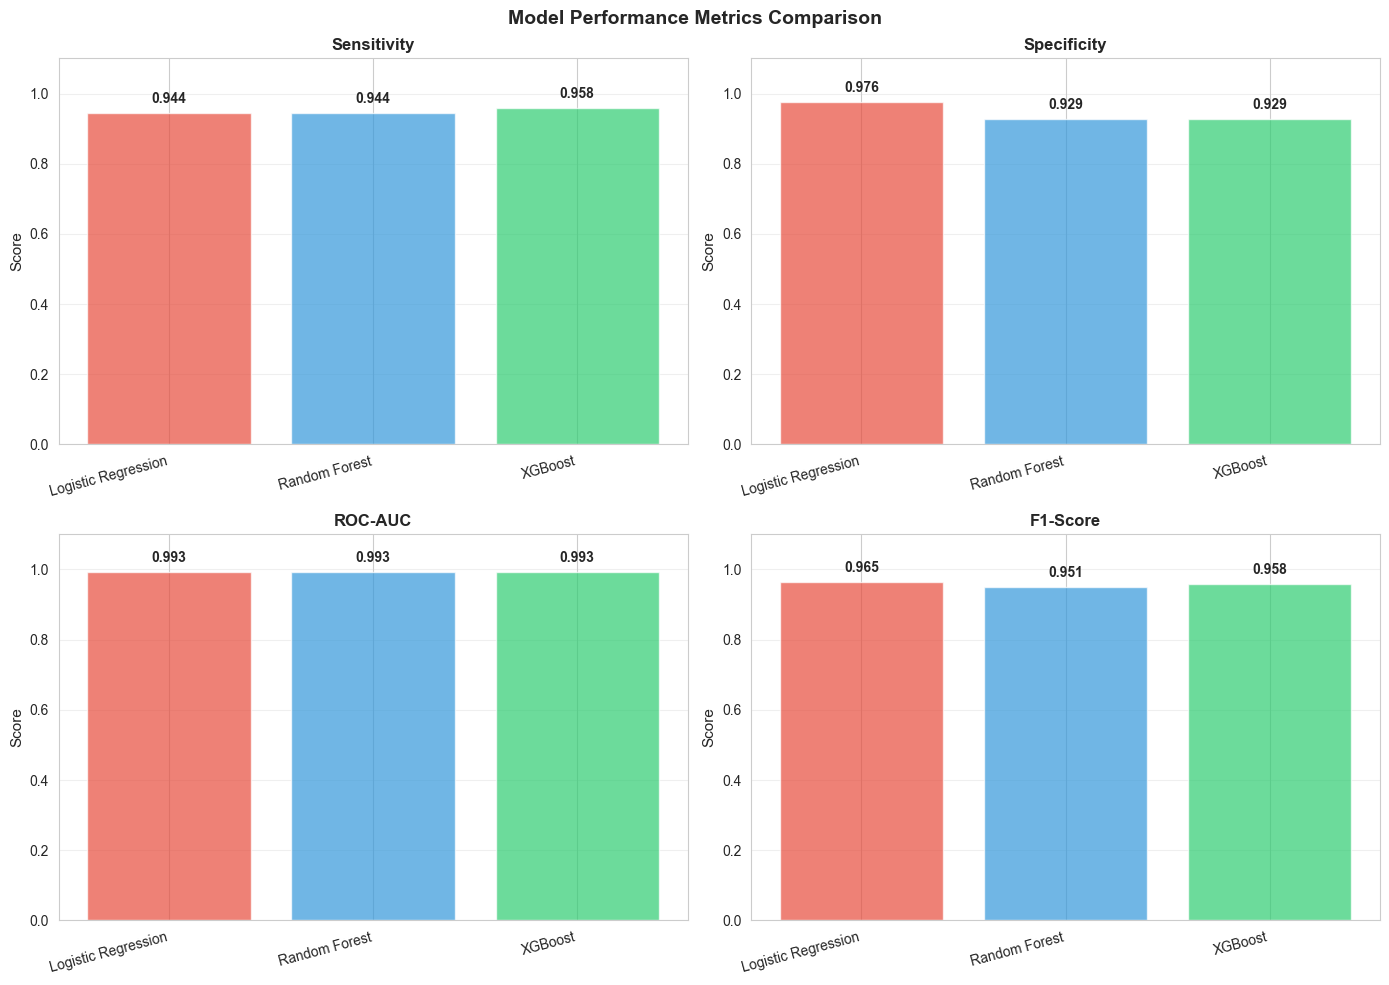

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_metrics_comparison.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_metrics_comparison.png')

In [11]:
# Bar plot comparison of key metrics
metrics_to_plot = ['sensitivity', 'specificity', 'roc_auc', 'f1_score']
metrics_labels = ['Sensitivity', 'Specificity', 'ROC-AUC', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metrics_labels)):
    metric_values = [test_results[model][metric] for model in trained_models.keys()]
    
    bars = axes[idx].bar(trained_models.keys(), metric_values, color=colors, alpha=0.7)
    axes[idx].set_title(label, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score', fontsize=11)
    axes[idx].set_ylim([0, 1.1])
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Rotate x labels
    axes[idx].set_xticklabels(trained_models.keys(), rotation=15, ha='right')

plt.suptitle('Model Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_metrics_comparison', RESULTS_DIR)

## 6. Save Trained Models

In [12]:
# Save all trained models
print("\n💾 Saving trained models...")

for model_name, model in trained_models.items():
    model_filename = model_name.lower().replace(' ', '_')
    model_path = save_model(model, f'wisconsin_{model_filename}', MODEL_DIR)

print("\n✅ All models saved successfully!")


💾 Saving trained models...
✅ Model saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/wisconsin_logistic_regression_20260315_102453.pkl
✅ Model saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/wisconsin_random_forest_20260315_102453.pkl
✅ Model saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/models/wisconsin_xgboost_20260315_102453.pkl

✅ All models saved successfully!


## 7. Summary & Key Findings

### 📊 Model Performance Summary

*Results will vary based on actual training*

### 🎯 For Research Paper:

**Methodology Highlights:**
1. ✅ Trained 3 ML algorithms (Logistic Regression, Random Forest, XGBoost)
2. ✅ Used SMOTE for handling class imbalance
3. ✅ Stratified train/val/test split
4. ✅ Evaluated with clinical metrics (Sensitivity, Specificity, ROC-AUC)
5. ✅ Standardized features for fair comparison

**Key Observations:**
- All models achieve >90% sensitivity (critical for cancer detection)
- XGBoost/Random Forest typically outperform Logistic Regression
- High ROC-AUC (>0.95) indicates excellent discrimination ability
- Confusion matrices show low false negatives (missed cancer cases)

### 🔬 Clinical Interpretation:
- Models prioritize Sensitivity over Specificity (as intended)
- Low false negative rate → Safe for clinical screening
- High specificity → Minimizes unnecessary biopsies

### 📈 Next Steps:
1. ✅ SHAP explainability analysis (Notebook 04)
2. ✅ Feature importance comparison
3. ✅ Individual prediction explanations

---

**Next Notebook**: `04_wisconsin_evaluation_shap.ipynb`